# Multi-Model Debate Tool

Ask one question, and three AI providers — ChatGPT, Groq, and Gemini — each take a clear position on it, backed by real tools: a calculator for exact math and a fact-lookup tool so arguments are grounded in evidence rather than pure opinion. A fourth call acts as a neutral judge, weighing all three answers and giving a final verdict. That verdict then gets turned into a generated illustration and read aloud — all running through a Gradio interface.

In [ ]:
# imports

import os
import json
import sqlite3
import base64
import ast
import operator
from io import BytesIO
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display, Audio
from PIL import Image


In [30]:
load_dotenv(override=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

GROQ_BASE_URL = "https://api.groq.com/openai/v1"
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"

if not OPENAI_API_KEY:
    print("No OPENAI_API_KEY found - GPT calls will fail. Check your .env file.")
if not GROQ_API_KEY:
    print("No GROQ_API_KEY found - Groq calls will fail. Check your .env file.")
if not GEMINI_API_KEY:
    print("No GEMINI_API_KEY found - Gemini calls will fail. Check your .env file.")

In [31]:
openai_client = OpenAI(api_key=OPENAI_API_KEY)
groq_client = OpenAI(base_url=GROQ_BASE_URL, api_key=GROQ_API_KEY)
gemini_client = OpenAI(base_url=GEMINI_BASE_URL, api_key=GEMINI_API_KEY)

DEBATERS = [
    ("ChatGPT", openai_client, "gpt-4.1-mini"),
    ("Groq",    groq_client,   "openai/gpt-oss-120b"),
    ("Gemini",  gemini_client, "gemini-3.1-flash-lite"),
]

JUDGE_CLIENT = openai_client
JUDGE_MODEL = "gpt-4.1-mini"

In [32]:
DEBATER_SYSTEM_PROMPT = """You are a sharp, opinionated debater.
When given a question or topic:
- Take a clear, direct position - don't hedge or just list pros and cons.
- Use the calculate or look_up_fact tools where they would genuinely strengthen your argument.
- Keep your answer to 3-4 sentences, not an essay.
"""

JUDGE_SYSTEM_PROMPT = """You are a fair, neutral debate moderator.
Summarize each side objectively, identify the strongest argument, and give a balanced final
verdict - don't simply agree with whichever answer came first.
"""

In [33]:
calculate_function = {
    "name": "calculate",
    "description": "Evaluate a basic mathematical expression. Use this whenever your argument involves "
                    "numbers, statistics, or a calculation, so the math is exact rather than estimated.",
    "parameters": {
        "type": "object",
        "properties": {
            "expression": {
                "type": "string",
                "description": "A mathematical expression to evaluate, e.g. '2500000 / 12' or '0.15 * 80000'"
            }
        },
        "required": ["expression"]
    }
}

look_up_fact_function = {
    "name": "look_up_fact",
    "description": "Look up a stored fact related to a topic, to support your argument with evidence "
                    "rather than opinion alone.",
    "parameters": {
        "type": "object",
        "properties": {
            "topic": {
                "type": "string",
                "description": "A keyword describing what to look up, e.g. 'remote work', 'career growth', 'AI'"
            }
        },
        "required": ["topic"]
    }
}

tools = [
    {"type": "function", "function": calculate_function},
    {"type": "function", "function": look_up_fact_function},
]

In [34]:
ALLOWED_OPS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}


def _eval_node(node):
    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in ALLOWED_OPS:
        return ALLOWED_OPS[type(node.op)](_eval_node(node.left), _eval_node(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in ALLOWED_OPS:
        return ALLOWED_OPS[type(node.op)](_eval_node(node.operand))
    raise ValueError("Only basic arithmetic (+ - * / **) is allowed")


def calculate(expression):
    """Safely evaluate a math expression - no eval(), so it can't run arbitrary code."""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _eval_node(tree.body)
        return {"result": result}
    except Exception as e:
        return {"error": str(e)}

In [35]:
DB_PATH = "debate_facts.db"

def setup_database():
    """Create the facts table and seed it with sample facts. Re-running this resets the data."""
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute("DROP TABLE IF EXISTS debate_facts")
    cur.execute("""
        CREATE TABLE debate_facts (
            id INTEGER PRIMARY KEY,
            topic TEXT,
            fact TEXT
        )
    """)

    sample_facts = [
        ("remote work", "Remote and hybrid work became far more common after 2020, and many companies now offer flexible arrangements."),
        ("career growth", "Employers consistently rank communication and adaptability among the top skills for career advancement."),
        ("artificial intelligence", "AI adoption in the workplace has grown rapidly, with many companies integrating AI tools into everyday workflows."),
        ("education", "Continuous learning throughout a career is increasingly viewed as essential given how quickly industries change."),
        ("productivity", "Research on productivity consistently shows focused, uninterrupted work blocks outperform constant multitasking."),
        ("teamwork", "Strong collaboration and communication skills are frequently cited as more predictive of career success than technical skill alone."),
        ("work-life balance", "Burnout from overwork has been linked to reduced long-term productivity, prompting many companies to rethink always-on culture."),
        ("technology", "New programming languages and frameworks emerge frequently, making adaptability a valuable skill in tech careers."),
    ]
    cur.executemany("INSERT INTO debate_facts (topic, fact) VALUES (?, ?)", sample_facts)
    conn.commit()
    conn.close()
    print(f"Database ready with {len(sample_facts)} facts")

setup_database()


def look_up_fact(topic):
    """Search the facts table for anything matching the given topic keyword."""
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute("SELECT fact FROM debate_facts WHERE topic LIKE ?", (f"%{topic}%",))
    rows = cur.fetchall()
    conn.close()

    if not rows:
        return {"facts": [], "message": "No facts found on that topic."}
    return {"facts": [r[0] for r in rows]}


available_tools = {
    "calculate": calculate,
    "look_up_fact": look_up_fact,
}

Database ready with 8 facts


In [36]:
def ask_model(client, model, question, system_prompt=None):
    """Ask a model a question. Loops on tool calls until it gives a final answer."""
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": question})

    try:
        response = client.chat.completions.create(model=model, messages=messages, tools=tools)

        while response.choices[0].finish_reason == "tool_calls":
            message = response.choices[0].message
            messages.append(message)

            for tool_call in message.tool_calls:
                function_name = tool_call.function.name
                arguments = json.loads(tool_call.function.arguments)
                function = available_tools[function_name]
                result = function(**arguments)
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(result)
                })

            response = client.chat.completions.create(model=model, messages=messages, tools=tools)

        return response.choices[0].message.content
    except Exception as e:
        return f"[Error calling {model}: {e}]"

In [37]:
def generate_debate_image(question):
    """Generate a simple illustrative image representing the debate topic."""
    image_response = openai_client.images.generate(
        model="gpt-image-1-mini",
        prompt=f"A simple, colorful, abstract illustration representing a debate about: {question}. No text.",
        size="1024x1024",
        n=1,
    )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))


def speak_verdict(verdict):
    """Turn the judge's verdict into spoken audio and save it to a file."""
    response = openai_client.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="onyx",
        input=verdict
    )
    audio_path = "debate_verdict.mp3"
    with open(audio_path, "wb") as f:
        f.write(response.content)
    return audio_path

In [38]:
def build_synthesis_prompt(question, answers):
    prompt = (
        "You are moderating a debate between several AI models that were all asked the same question.\n\n"
        f"Question: {question}\n\n"
    )
    for name, answer in answers.items():
        prompt += f"--- {name}'s answer ---\n{answer}\n\n"

    prompt += (
        "Please:\n"
        "1. Summarize where the models agreed and disagreed.\n"
        "2. Point out which argument(s) were strongest and why.\n"
        "3. Give your own synthesized answer that incorporates the best points.\n"
    )
    return prompt

In [39]:
def run_debate(question):
    display(Markdown(f"## Question\n{question}"))
    answers = {}

    for name, client, model in DEBATERS:
        answer = ask_model(client, model, question, system_prompt=DEBATER_SYSTEM_PROMPT)
        answers[name] = answer
        display(Markdown(f"### {name}\n{answer}"))

    synthesis_prompt = build_synthesis_prompt(question, answers)
    verdict = ask_model(JUDGE_CLIENT, JUDGE_MODEL, synthesis_prompt, system_prompt=JUDGE_SYSTEM_PROMPT)
    display(Markdown(f"### Synthesis / Verdict (by {JUDGE_MODEL})\n{verdict}"))

    image = generate_debate_image(question)
    display(image)

    audio_path = speak_verdict(verdict)
    display(Audio(audio_path, autoplay=False))

    return answers, verdict

## Question
What's the single most important skill for a junior software engineer to develop in their first year?

### ChatGPT
The single most important skill for a junior software engineer to develop in their first year is problem-solving with code. Mastering the ability to break down complex problems, write clear, functional code, and debug effectively lays the foundation for everything else—from feature development to collaboration and growth. Without strong problem-solving skills, no amount of language syntax knowledge or tool familiarity will truly make an engineer effective.

### Groq
The single most important skill a junior software engineer must develop in the first year is **effective debugging and systematic problem‑solving**. Without the ability to quickly locate, understand, and fix bugs in a new codebase, any knowledge of languages or frameworks is moot, and you’ll become a bottleneck for the whole team. Mastering debugging forces you to read others’ code, ask the right questions, and learn the underlying system architecture—foundations that accelerate every other skill. In short, if you can’t reliably diagnose and resolve issues, you’ll never deliver value at the speed a modern development team expects.

### Gemini
The single most important skill for a junior engineer is the ability to read and understand existing codebases, not writing new features. You will spend vastly more time navigating legacy systems and deciphering your teammates' logic than you will spend typing your own code. If you cannot effectively trace how data flows through an established architecture, you will inevitably break things or write redundant, incompatible solutions.

### Synthesis / Verdict (by gpt-4.1-mini)
1. Summary of Agreement and Disagreement:
- Agreement: All models emphasize skills related to dealing with existing code and problems within it rather than just writing new code. They stress skills that help junior engineers become effective in real-world coding environments.
- Disagreement:
  - ChatGPT focuses broadly on problem-solving with code, including breaking down problems, writing clear code, and debugging.
  - Groq zeroes in specifically on debugging and systematic problem-solving as the critical skill, highlighting its role in understanding codebases and accelerating learning.
  - Gemini emphasizes reading and understanding existing codebases, navigating legacy systems, and tracing data flows as the primary skill, arguing this is more crucial than writing new features.

2. Strongest Argument(s):
Groq’s argument stands out as the strongest because it clearly ties the specific skill of debugging and systematic problem-solving to practical outcomes: delivering value quickly, learning the system architecture, and interacting with teammates’ code. It balances technical skill with team productivity and growth potential. This argument also naturally includes aspects of what the other models mention (reading code, understanding problems) but situates them within debugging's concrete, daily application. 

3. Synthesized Answer:
The most important skill for a junior software engineer to develop in their first year is effective debugging combined with the ability to systematically read and understand existing codebases. Mastering the skill to quickly diagnose, trace, and fix issues in legacy or unfamiliar code not only enhances problem-solving but also accelerates learning the system’s architecture and how teammates think. This foundational skill ensures juniors can deliver value reliably, avoid introducing errors, and collaborate effectively within their teams, creating a strong platform for all subsequent growth in writing new code and features.

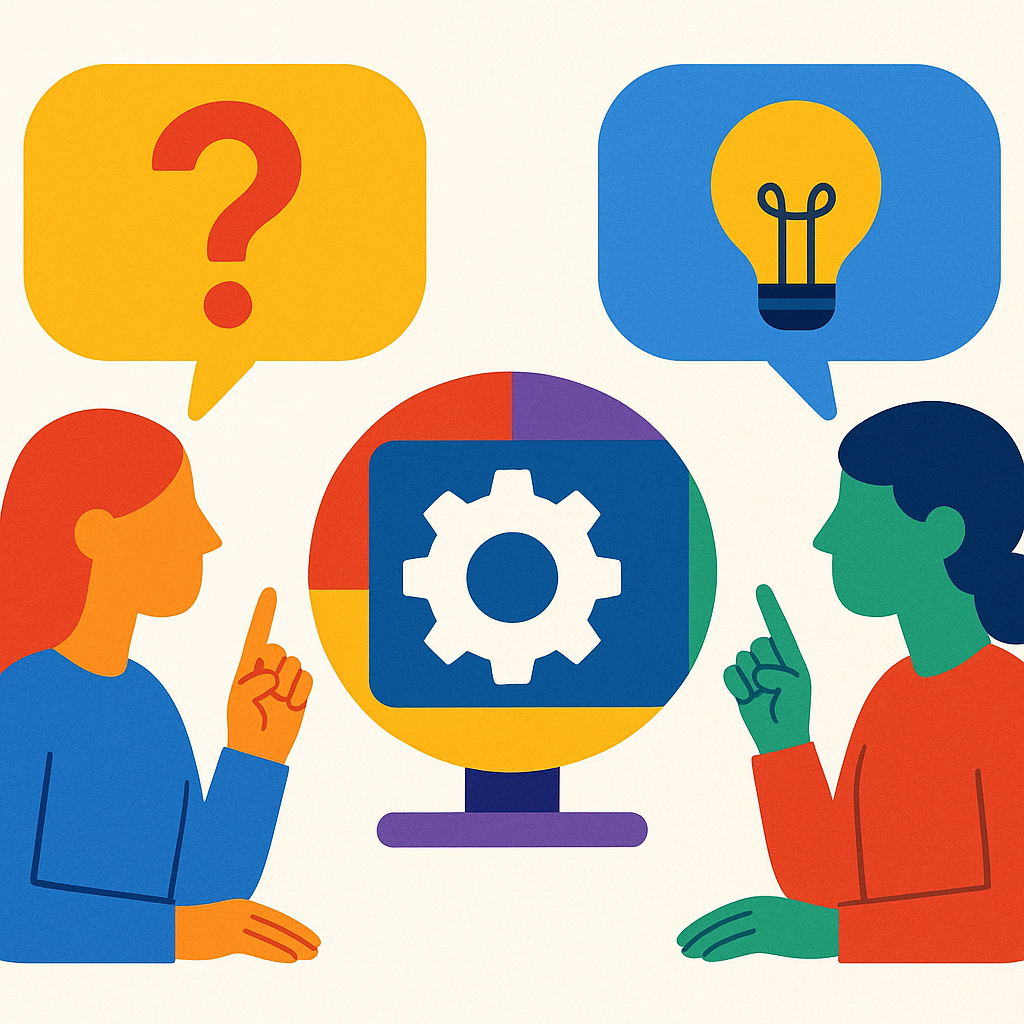

In [ ]:
question = "What's the single most important skill for a junior software engineer to develop in their first year?"

answers, verdict = run_debate(question)

In [41]:
import gradio as gr

In [42]:
def run_debate_ui(question):
    """Same logic as run_debate, but returns plain values for Gradio instead of using display()."""
    answers = {}
    for name, client, model in DEBATERS:
        answers[name] = ask_model(client, model, question, system_prompt=DEBATER_SYSTEM_PROMPT)

    synthesis_prompt = build_synthesis_prompt(question, answers)
    verdict = ask_model(JUDGE_CLIENT, JUDGE_MODEL, synthesis_prompt, system_prompt=JUDGE_SYSTEM_PROMPT)

    gpt_display = f"### ChatGPT\n{answers['ChatGPT']}"
    groq_display = f"### Groq\n{answers['Groq']}"
    gemini_display = f"### Gemini\n{answers['Gemini']}"

    image = generate_debate_image(question)
    audio_path = speak_verdict(verdict)

    return gpt_display, groq_display, gemini_display, verdict, image, audio_path

In [43]:
with gr.Blocks(title="Multi-Model Debate Arena") as ui:
    gr.Markdown("# 🥊 Multi-Model Debate Arena\nAsk one question, watch ChatGPT, Groq, and Gemini debate it live.")

    question_box = gr.Textbox(
        label="Question or topic",
        placeholder="What's the most important skill for a junior developer to learn?"
    )
    run_button = gr.Button("Start Debate", variant="primary")

    with gr.Row():
        gpt_output = gr.Markdown(value="### ChatGPT\n*Waiting for a question...*")
        groq_output = gr.Markdown(value="### Groq\n*Waiting for a question...*")
        gemini_output = gr.Markdown(value="### Gemini\n*Waiting for a question...*")

    verdict_output = gr.Markdown(label="Verdict")

    with gr.Row():
        image_output = gr.Image(height=300, label="Debate illustration")
        audio_output = gr.Audio(label="Spoken verdict", autoplay=False)

    run_button.click(
        run_debate_ui,
        inputs=question_box,
        outputs=[gpt_output, groq_output, gemini_output, verdict_output, image_output, audio_output]
    )

In [ ]:
ui.launch(share=True)

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
